First we imported the  neccery libraries.

In [43]:
!pip install arabic-reshaper python-bidi


In [44]:
!pip install jdatetime

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Now we read the data frame. The file is in the google driver so we import drive library from google colab to access the data frame.

In [46]:
from google.colab import drive

drive.mount("/content/drive")

data_frame_path = "/content/drive/MyDrive/Divar.csv"

data_frame = pd.read_csv(data_frame_path)

data_frame.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_3023/797180065.py:7: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frame = pd.read_csv(data_frame_path)


,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,residential-rent,apartment-rent,ahvaz,mellirah,2024-09-01 00:00:00,NaN,اپارتمان ۱۰۰متری واحد جلو دارای دو اتاق خواب ک...,اپارتمان ۱۰۰متری ملی راه واحد جلو,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,commercial-rent,office-rent,kermanshah,NaN,2024-11-01 00:00:00,NaN,♦مشاورین املاک سیب♦\n✅️کد:G۱۰۵\n♦با سالها سابق...,واحداداری ۸۰متری ۲۲بهمن(برق),مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,residential-sell,apartment-sell,tehran,dardasht,2024-09-01 00:00:00,مشاور املاک,♡♡♡♡♡♡بنام خدا♡♡♡♡♡♡\n♡♡♡عرض ادب واحترام♡♡♡\n♡...,اپارتمان ۱۰۰متری طبقه۳و۴ فول دردشت شمالی,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,500.0
8,8,residential-sell,apartment-sell,mahdasht-city,NaN,2024-06-01 00:00:00,مشاور املاک,با سلام\n\nاملاک بزرگ اتحاد با ۲شعبه فعال با ف...,۷۸متری دوبحرنورگیر بازسازی شده شیک سندتک برگ,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,500.0
9,9,residential-sell,apartment-sell,mashhad,faramarzabbasi,2024-10-01 00:00:00,NaN,اول رسالت فرد نزدیک به حاشیه فرامرز .. ساکنین...,متراژ ۸۰ متر فرامرز نزدیک حاشیه,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Lets see how much of the columns include Nan values.

In [47]:
data_frame.isna().sum()

,0
Unnamed: 0,0
cat2_slug,0
cat3_slug,1
city_slug,2
neighborhood_slug,562861
...,...
rent_price_on_special_days,989537
rent_price_at_weekends,986449
location_latitude,344392
location_longitude,344392


For the task number 6 in the statical section we need rent_values, rent_mode,
created_at_month

In [48]:
target_df = data_frame[["rent_value", "created_at_month"]]
target_df.head(10)


,rent_value,created_at_month
0,NaN,2024-08-01 00:00:00
1,NaN,2024-05-01 00:00:00
2,26000000.0,2024-10-01 00:00:00
3,95000000.0,2024-06-01 00:00:00
4,NaN,2024-05-01 00:00:00
5,6000000.0,2024-09-01 00:00:00
6,16000000.0,2024-11-01 00:00:00
7,NaN,2024-09-01 00:00:00
8,NaN,2024-06-01 00:00:00
9,NaN,2024-10-01 00:00:00


Now we change the created time to the solar calender date but we just need months.

In [49]:
from sklearn.preprocessing import FunctionTransformer

def trun_grogorian_solar_month(data_frame : pd.DataFrame):
  # Here we change the data type to the pd.DateTime.
  data_frame["created_at_month"] = pd.to_datetime(data_frame["created_at_month"])

  # Here we just take month and remove the created_at_month
  data_frame["month"] = data_frame["created_at_month"].dt.month

  # Here we turn the month of the Gregorian date into solar calender.
  map_gregorian_solar = {
      1 : "دی", 2 : "بهمن", 3 : "اسفند", 4 : "فروردین", 5 : "اردیبهشت", 6 : "خرداد",
      7 : "تیر", 8 : "مرداد", 9 : "شهریور", 10 : "مهر", 11 : "آبان", 12 : "آذر"
  }
  data_frame["month"] = data_frame["month"].map(map_gregorian_solar)

  return data_frame

# Enableing the function to be used in the PipeLine.
trun_grogorian_solar_month = FunctionTransformer(trun_grogorian_solar_month)



In this Part we fill Nan values of the ren_value.

In [50]:
# We just need the data which does not have the rent_value. -> with the logiv that if a row does not have a rent_value
# it is for sale or a nan value of the rent category.
labels = target_df["rent_value"].isna()
target_df = target_df[~labels]

def fill_nan_rent_value(data_frame : pd.DataFrame):
  # Fill the Nan values based on the median of elements grouped by month.
  rent_value_month_median = data_frame.groupby(["month"]).median()
  data_frame["rent_value"] = data_frame["rent_value"].fillna(
      data_frame.groupby("month")["rent_value"].transform("median")
  )
  return data_frame

# Enableing the function to be used in the PipeLine.
fill_nan_rent_value = FunctionTransformer(fill_nan_rent_value)

target_df.head(10)

print(target_df.isna().sum())


rent_value          0
created_at_month    0
dtype: int64


In [51]:
import jdatetime
from sklearn.preprocessing import FunctionTransformer

def trun_grogorian_solar_year(data_frame : pd.DataFrame):
  # Convertnig to the DateTime.
  data_frame["created_at_month"] = pd.to_datetime(data_frame["created_at_month"])

  # Turning into the persian calender.
  data_frame["Year"] = data_frame["created_at_month"].apply(lambda d: jdatetime.date.fromgregorian(date=d.date()).year)

  return data_frame

trun_grogorian_solar_year = FunctionTransformer(trun_grogorian_solar_year)


In [52]:
target_df = trun_grogorian_solar_month.transform(target_df)
target_df = fill_nan_rent_value.transform(target_df)
target_df = trun_grogorian_solar_year.transform(target_df)

In [53]:
# Operations on the target_df
target_df = target_df.drop(columns=["created_at_month"])

target_df = target_df.groupby(["Year", "month"])["rent_value"].mean()
target_df = pd.DataFrame(target_df)

In [54]:
target_df.index

MultiIndex([(1401,      'تیر'),
            (1401,    'خرداد'),
            (1401,    'مرداد'),
            (1402,     'آبان'),
            (1402,      'آذر'),
            (1402,    'اسفند'),
            (1402,     'بهمن'),
            (1402,      'تیر'),
            (1402,       'دی'),
            (1402,   'شهریور'),
            (1402,    'مرداد'),
            (1402,      'مهر'),
            (1403,     'آبان'),
            (1403,      'آذر'),
            (1403, 'اردیبهشت'),
            (1403,     'بهمن'),
            (1403,      'تیر'),
            (1403,    'خرداد'),
            (1403,       'دی'),
            (1403,   'شهریور'),
            (1403,  'فروردین'),
            (1403,    'مرداد'),
            (1403,      'مهر')],
           names=['Year', 'month'])

Plotting the histogram.(We need arabic reshape for the plot)

[1401, 1402, 1403]


/tmp/ipykernel_3023/2929812733.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[index].legend()
/tmp/ipykernel_3023/2929812733.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[index].legend()
/tmp/ipykernel_3023/2929812733.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[index].legend()


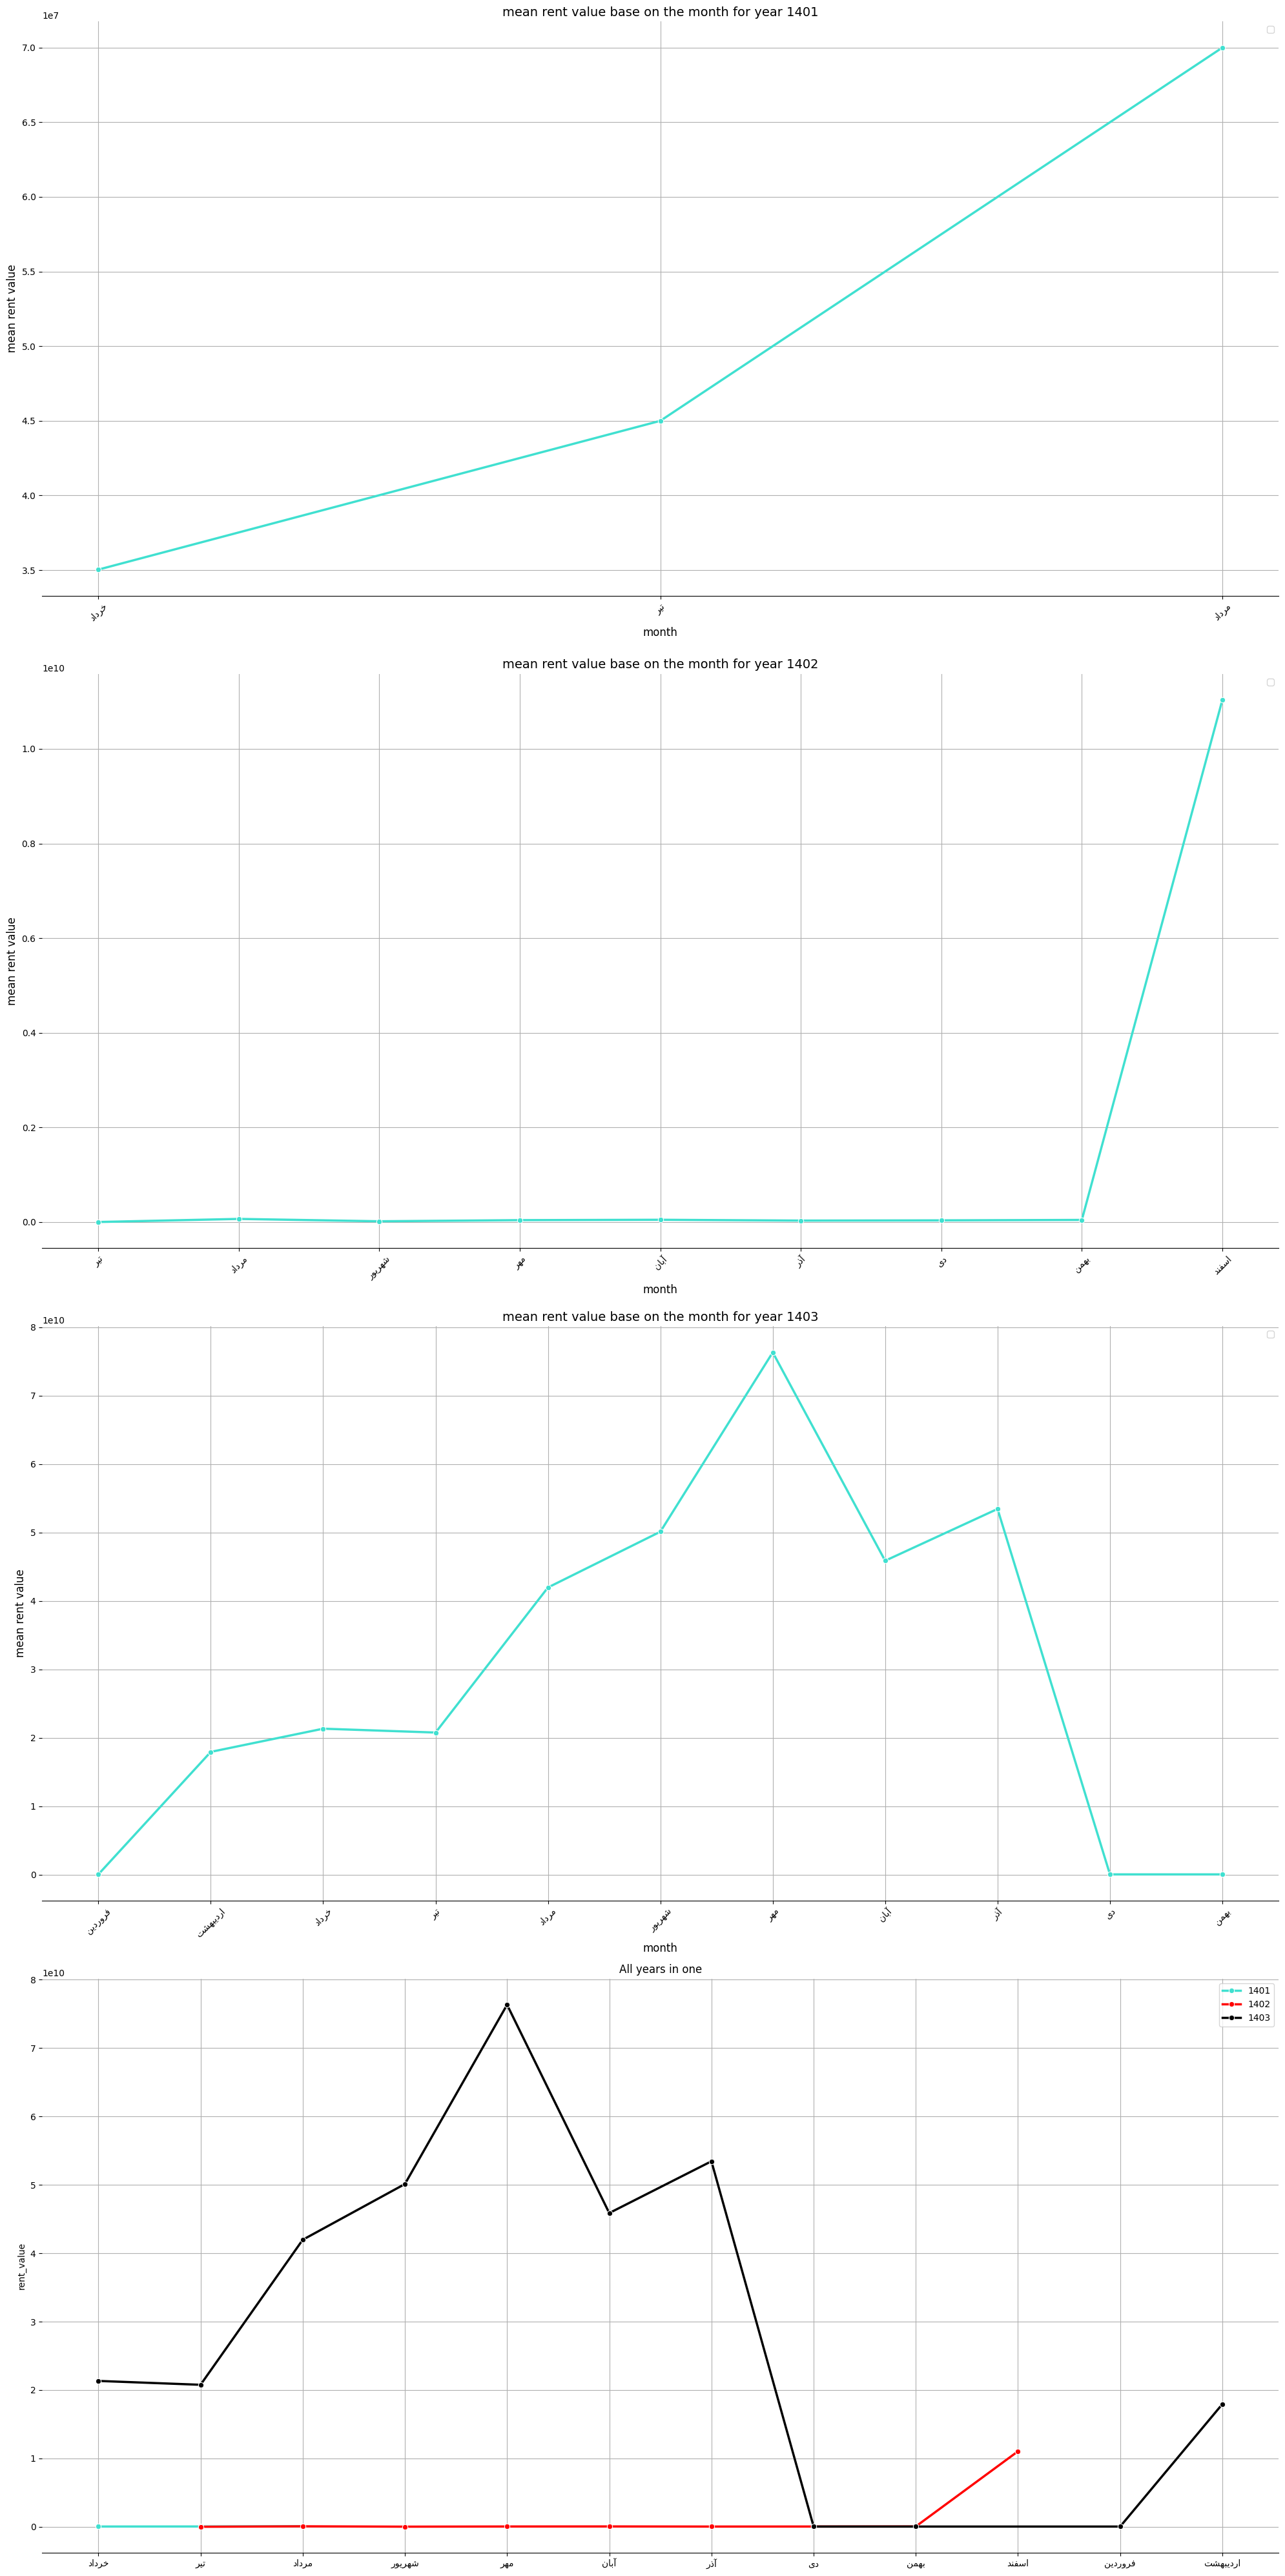

In [55]:
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def fix_fa(text: str) -> str:
    return get_display(arabic_reshaper.reshape(str(text)))

month_order = [
    "فروردین",
    "اردیبهشت",
    "خرداد",
    "تیر",
    "مرداد",
    "شهریور",
    "مهر",
    "آبان",
    "آذر",
    "دی",
    "بهمن",
    "اسفند",
]

colors = ["turquoise", "red", "black"]
figure, axes = plt.subplots(4, 1, figsize=(20, 40))
years = sorted(target_df.index.unique(level="Year"))
print(years)
for index, year in zip(range(3), years):
  target_grouped = target_df.loc[year]

  valid_months = [m for m in month_order if m in target_grouped.index]
  target_grouped = target_grouped.reindex(valid_months)

  current_axes = axes[index]

  x_labels = [fix_fa(m) for m in target_grouped.index]
  y_values = target_grouped["rent_value"]

  sns.lineplot(x=x_labels, y=y_values, color="turquoise", ax=axes[index], marker='o', linewidth=2.5)

  axes[index].tick_params(axis='x', rotation=45)
  axes[index].set_title(f"mean rent value base on the month for year {year}", fontsize=14)
  axes[index].set_xlabel("month", fontsize=12)
  axes[index].set_ylabel("mean rent value", fontsize=12)

  axes[index].spines["top"].set_visible(False)
  axes[index].spines["left"].set_visible(False)
  axes[index].spines["right"].set_visible(False)
  axes[index].grid()
  axes[index].legend()


  # This is for ploting in the all of them in one ax.
  sns.lineplot(x=x_labels, y=y_values, color=colors[index], ax=axes[3], marker='o', linewidth=2.5, label=year)


axes[3].set_title("All years in one")
axes[3].spines["top"].set_visible(False)
axes[3].spines["left"].set_visible(False)
axes[3].spines["right"].set_visible(False)
axes[3].grid()
axes[3].legend()

plt.tight_layout()


In this part we start the section 7 of the statical part.
So we make a copy of the main data frame in an attemp to work with it in section 7

In [56]:
data_frame_7 = data_frame.copy()
data_frame_7 = data_frame_7[["price_value", 'created_at_month', "city_slug", "rent_value"]]

In this part we try convert the types of the (created_at_month) column into pd.DateTime.


In [57]:
data_frame_7 = trun_grogorian_solar_year.transform(data_frame_7)

data_frame_7

,price_value,created_at_month,city_slug,rent_value,Year
0,NaN,2024-08-01,karaj,NaN,1403
1,8.500000e+09,2024-05-01,tehran,NaN,1403
2,NaN,2024-10-01,tehran,26000000.0,1403
3,NaN,2024-06-01,tehran,95000000.0,1403
4,5.750000e+09,2024-05-01,mashhad,NaN,1403
...,...,...,...,...,...
999995,7.470000e+09,2024-07-01,kermanshah,NaN,1403
999996,NaN,2024-07-01,tehran,45000000.0,1403
999997,3.200000e+09,2024-11-01,yazd,NaN,1403
999998,NaN,2024-09-01,bandar-anzali,NaN,1403


In this part we full fill the nan values with median of the price_value grouped by the year.

In [58]:
# The number of the city slug which has the Nan values is too low in the comparasion with the one million line.
# So we can drop them.
city_labels = (data_frame_7["city_slug"].isna())
data_frame_7 = data_frame_7[~city_labels]
rent_labels = (data_frame_7["rent_value"].isna())
data_frame_7 = data_frame_7[rent_labels]
data_frame_7 = data_frame_7.drop(columns=["rent_value", "created_at_month"])

def fill_price_value(data_frame : pd.DataFrame):
  # Removing the rows with Nan city_slug.
  data_frame = data_frame.dropna(subset=["city_slug"])
  data_frame['price_value'] = data_frame['price_value'].fillna(
      data_frame.groupby(['city_slug', 'Year'])['price_value'].transform('median')
  )
  return data_frame

fill_price_value = FunctionTransformer(fill_price_value)
data_frame_7 = fill_price_value.transform(data_frame_7)


def remove_outliers_iqr_price_value(df, column='price_value'):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Some cities may need more money to buy a house and may be removed .
def clean_and_aggregate(df):
    df_clean = df.dropna(subset=["city_slug", "price_value"]).groupby(
        ["city_slug", "Year"], group_keys=False
    ).apply(remove_outliers_iqr_price_value)

    return df_clean

clean_and_aggregate = FunctionTransformer(clean_and_aggregate)
data_frame_7 = clean_and_aggregate.transform(data_frame_7)


/tmp/ipykernel_3023/4241540543.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(remove_outliers_iqr_price_value)


Now we just plot the bar with sns.(without considering the inflation)

In [59]:
cpi_rates = {
    1400 : 719,
    1401 : 1031,
    1402 : 1480,
    1403 : 2140
}

data_frame_7_cpi = data_frame_7.copy()
cpi_frame = data_frame_7_cpi.index.map(cpi_rates)
data_frame_7_cpi["price_value"] = (data_frame_7_cpi["price_value"] / cpi_frame) * cpi_rates[1400]

data_frame_7 = data_frame_7.drop(columns=["city_slug"])
data_frame_7 = data_frame_7.groupby("Year").mean()
data_frame_7 = pd.DataFrame(data_frame_7)
data_frame_7 = data_frame_7.iloc[1:]

data_frame_7_cpi

,price_value,city_slug,Year
540,NaN,Iranshahr,1403
4056,NaN,Iranshahr,1403
4856,NaN,Iranshahr,1403
7580,NaN,Iranshahr,1403
7860,NaN,Iranshahr,1403
...,...,...,...
945474,NaN,ziyabar,1403
949468,NaN,ziyabar,1403
957047,NaN,ziyabar,1403
972193,NaN,ziyabar,1403


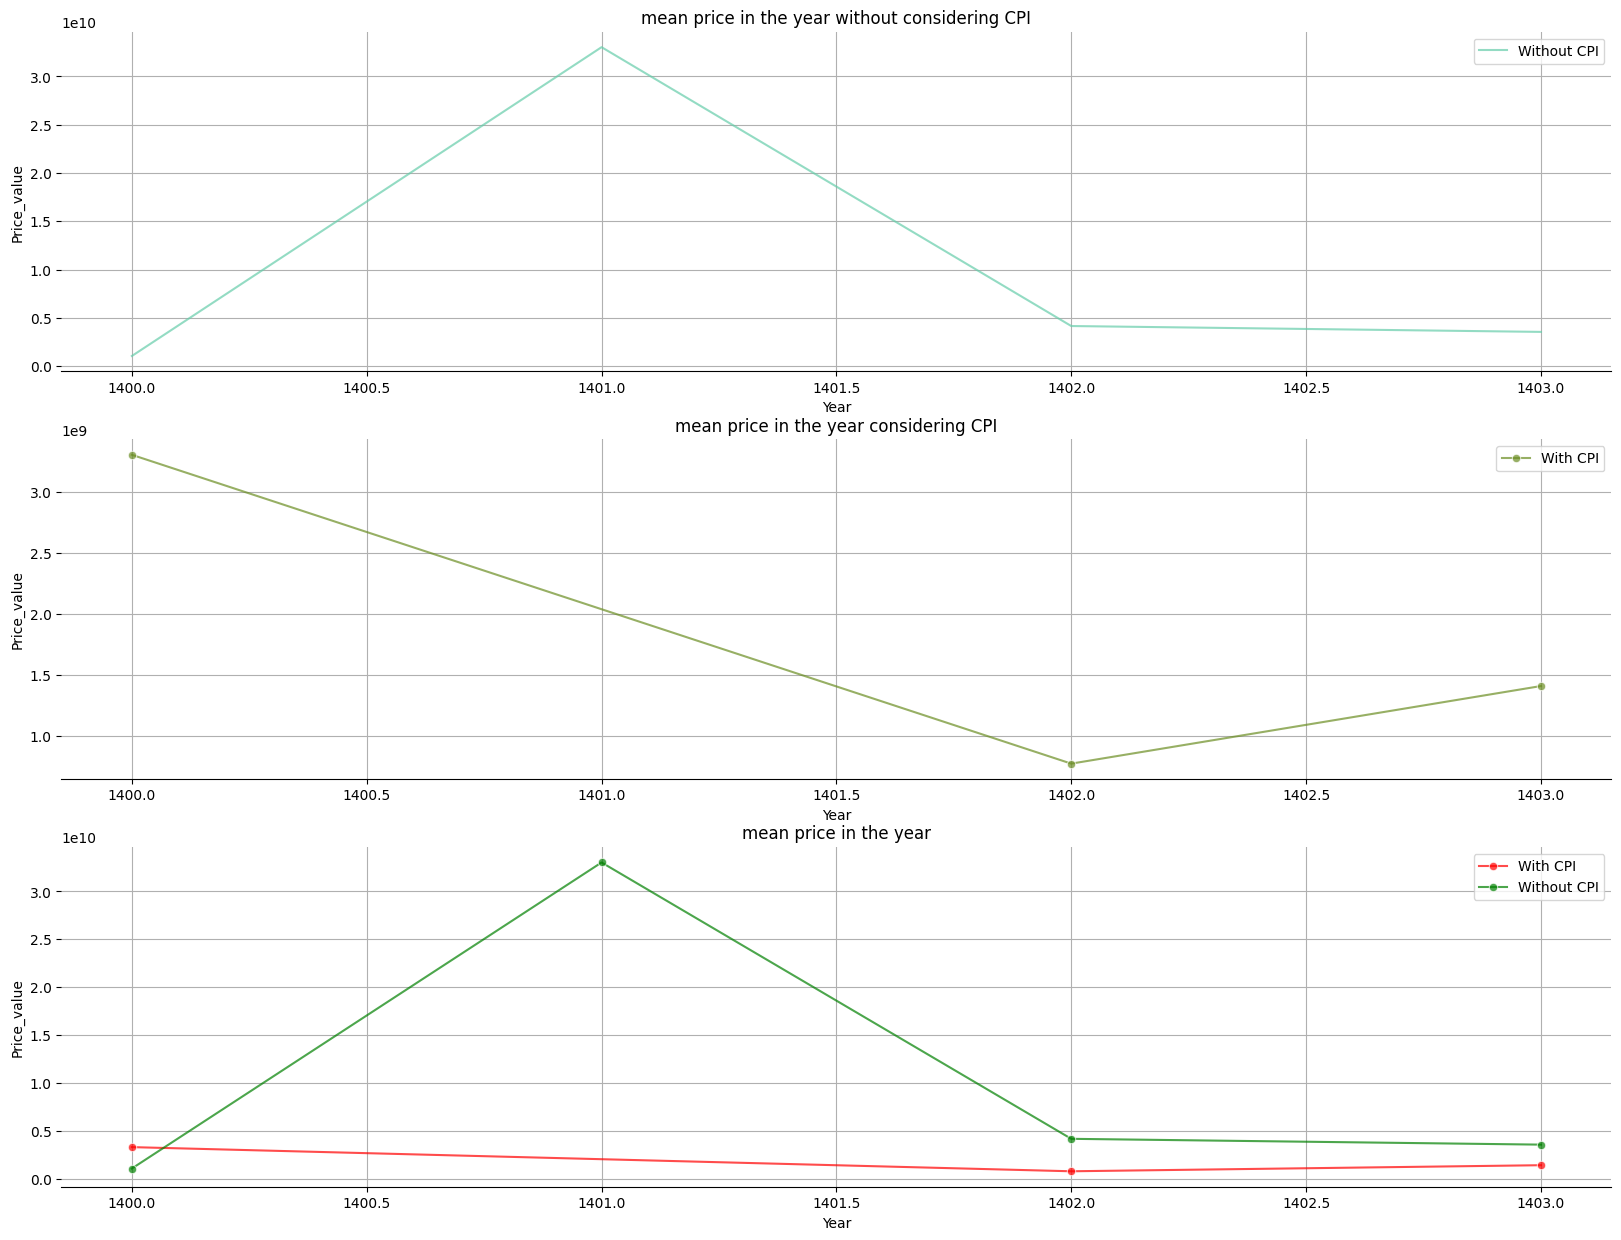

In [60]:
figure , axes = plt.subplots(3, 1, figsize=(20, 15))


sns.lineplot(
    x=data_frame_7.index,
    y=data_frame_7["price_value"],
    color="mediumaquamarine",
    ax = axes[0],
    alpha=0.7,
    label="Without CPI"
)
axes[0].spines["top"].set_visible(False)
axes[0].spines["left"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price_value")
axes[0].set_title("mean price in the year without considering CPI")
axes[0].grid()
axes[0].legend()


sns.lineplot(
    x=data_frame_7_cpi.index,
    y=data_frame_7_cpi["price_value"],
    color="olivedrab",
    marker='o',
    ax = axes[1],
    alpha=0.7,
    label="With CPI"
)
axes[1].spines["top"].set_visible(False)
axes[1].spines["left"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Price_value")
axes[1].set_title("mean price in the year considering CPI")
axes[1].grid()
axes[1].legend()

sns.lineplot(
    x=data_frame_7_cpi.index,
    y=data_frame_7_cpi["price_value"],
    color="red",
    marker='o',
    ax = axes[2],
    alpha=0.7,
    label="With CPI"
)


sns.lineplot(
    x=data_frame_7.index,
    y=data_frame_7["price_value"],
    color="green",
    marker='o',
    ax = axes[2],
    alpha=0.7,
    label="Without CPI"
)
axes[2].spines["top"].set_visible(False)
axes[2].spines["left"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Price_value")
axes[2].set_title("mean price in the year")
axes[2].grid()
axes[2].legend()



In this part we consider the inflation of each year.
Also we search the cpi and the other coefficients from the internet and effect it in our data.

Now we plot the real price_value

We start the section 3 of the second part of the static.

In [61]:
data_frame_3 = data_frame.copy()


In [62]:
data_frame_3 = data_frame_3[["has_business_deed", "price_value", "city_slug", "created_at_month"]]
data_frame_3 = data_frame_3.dropna(subset=["city_slug"])

# Some operations to fill the Nan values of the price_value and removing the outliers.
data_frame_3 = trun_grogorian_solar_year.transform(data_frame_3)
data_frame_3 = fill_price_value.transform(data_frame_3)
data_frame_3 = data_frame_3.dropna(subset=["city_slug", "price_value"]).groupby(
        ["city_slug", "Year"], group_keys=False
    ).apply(remove_outliers_iqr_price_value)



/tmp/ipykernel_3023/2993788030.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(remove_outliers_iqr_price_value)


In [63]:
data_frame_3 = pd.DataFrame(data_frame_3)

labels = data_frame_3.has_business_deed.isna()
target = data_frame_3[~labels]
has_business_True = target[target["has_business_deed"] == True]["price_value"]
has_business_False = target[target["has_business_deed"] == False]["price_value"]
has_business_True


,price_value
646340,8.000000e+08
957333,8.000000e+08
126179,1.600000e+09
181568,2.230000e+09
291369,1.600000e+09
...,...
189717,3.700000e+09
612543,3.550000e+09
660934,3.700000e+09
778574,1.700000e+09


Now we want to determine whether the distributions of the two samples are normal or not.

In [64]:
from scipy.stats import shapiro
shapiro_stat_True, shapiro_pvalue_True = shapiro(has_business_True)
shapiro_stat_False, shapiro_pvalue_False = shapiro(has_business_False)

print("The shapiro p_values : ")
print(f"Shapiro p_value True : {shapiro_pvalue_True}")
print(f"Shapiro p_value False : {shapiro_pvalue_False}")

The shapiro p_values : 
Shapiro p_value True : 4.300877400057761e-67
Shapiro p_value False : 1.5091101424060784e-74


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6841.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7197.
  res = hypotest_fun_out(*samples, **kwds)


The p_values show that the distributions are not normal so we use man_whitnee test.
The H0 : if a value of the property which has has_business_deed is greater equal than the property which does not have has_business_deed.

In [65]:
from scipy.stats import mannwhitneyu

u_state, p_value = mannwhitneyu(has_business_True, has_business_False, alternative="less")
print(f"p_value : {p_value}")

print("The p_value is less than alpha so the H0 can not be rejected.")

p_value : 0.4543775687532013
The p_value is less than alpha so the H0 can not be rejected.


The p_value is too much greater than the treshold so it show thta th H0 can not be rejcted.
The alternative assumption is false.

In [66]:
# For option you can plot some barplot. ask this one !!!!.
have_deed = target[target["has_business_deed"] == True]
not_have_deed = target[target["has_business_deed"] == False]

have_deed = pd.DataFrame(have_deed.groupby("Year")["price_value"].mean())
not_have_deed = pd.DataFrame(not_have_deed.groupby("Year")["price_value"].mean())

have_deed

,price_value
Year,
1402,5.456529e+09
1403,2.678811e+09


/tmp/ipykernel_3023/4242033913.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_3023/4242033913.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


(0.0, 85000000000.0)

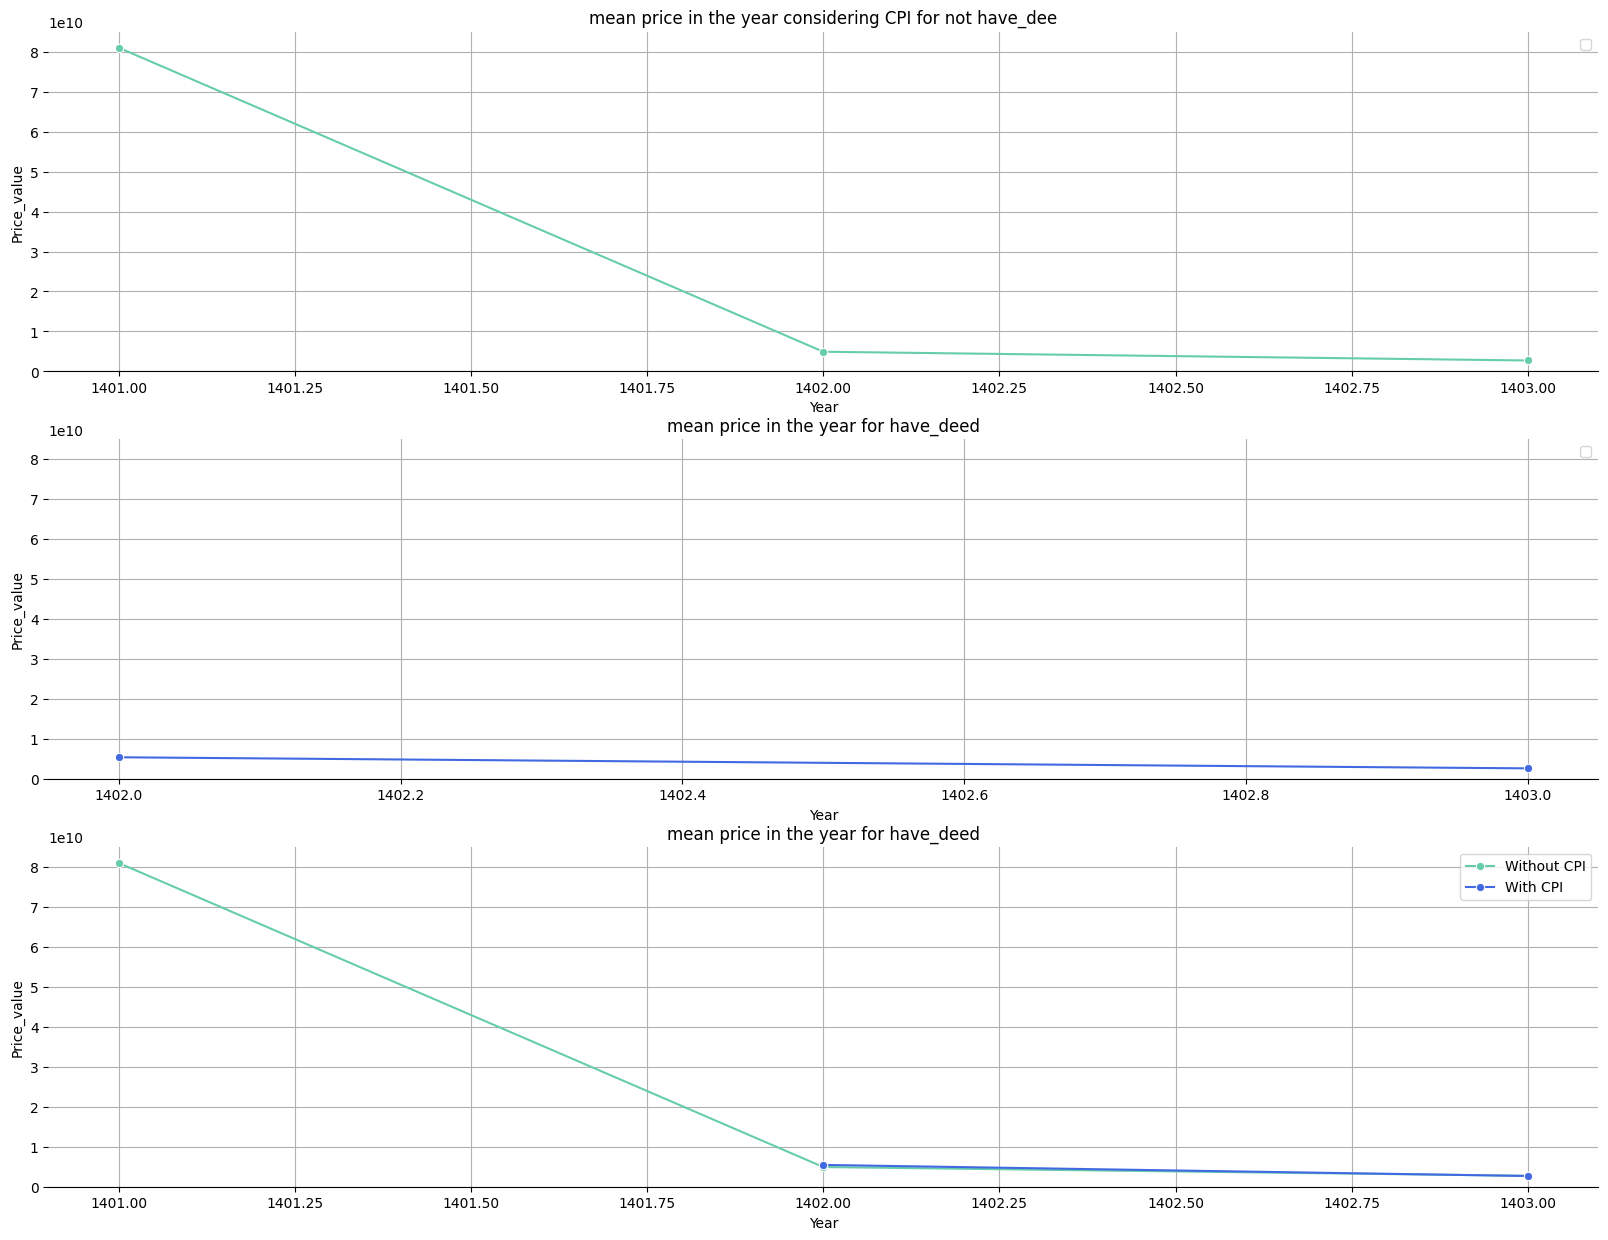

In [70]:
figure , axes = plt.subplots(3, 1, figsize=(20, 15))

sns.lineplot(
    x=not_have_deed.index,
    y=not_have_deed["price_value"],
    color="mediumaquamarine",
    marker='o',
    ax = axes[0],
)

sns.lineplot(
    x=have_deed.index,
    y=have_deed["price_value"],
    color="royalblue",
    marker='o',
    ax = axes[1],
)

sns.lineplot(
    x=not_have_deed.index,
    y=not_have_deed["price_value"],
    color="mediumaquamarine",
    marker='o',
    ax = axes[2],
    label="Without CPI"
)

sns.lineplot(
    x=have_deed.index,
    y=have_deed["price_value"],
    color="royalblue",
    marker='o',
    ax = axes[2],
    label="With CPI"
)

axes[0].spines["top"].set_visible(False)
axes[0].spines["left"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price_value")
axes[0].set_title("mean price in the year considering CPI for not have_dee")
axes[0].grid()
axes[0].legend()


axes[1].spines["top"].set_visible(False)
axes[1].spines["left"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Price_value")
axes[1].set_title("mean price in the year for have_deed")
axes[1].grid()
axes[1].legend()

axes[2].spines["top"].set_visible(False)
axes[2].spines["left"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Price_value")
axes[2].set_title("mean price in the year for have_deed")
axes[2].grid()
axes[2].legend()

# This limitation make them comparable in the plots.
max_y = 8.5e10

axes[0].set_ylim(0, max_y)
axes[1].set_ylim(0, max_y)
axes[2].set_ylim(0, max_y)